Install depedencies

In [ ]:
pip install scikit-learn evaluate datasets transformers gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.9 MB/s eta 0:00:00


Load GTZAN dataset (1000 different songs for music genre classification), each song is a 30 seconds sample

In [ ]:
from datasets import load_dataset

gtzan = load_dataset("ParitKansal/marsyas-gtzan")
gtzan #diplay dataset structure

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/630 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/441M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/429M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/436M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/999 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'genre'],
        num_rows: 999
    })
})

Spliting the data (because the dataset is blanced we can do it the easy way)

In [ ]:
gtzan = gtzan["train"].train_test_split(seed=42, shuffle=True, test_size=0.1)
gtzan

DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'genre'],
        num_rows: 899
    })
    test: Dataset({
        features: ['file', 'audio', 'genre'],
        num_rows: 100
    })
})

Let's take a look at the first audio file in our train set, and display the label's text instead of class number

In [ ]:
sample = gtzan["train"][0]
print(sample)
id2label_fn = gtzan["train"].features["genre"].int2str
print("Label text:", id2label_fn(sample["genre"]))

{'file': 'C:\\Users\\xelpmoc\\.cache\\huggingface\\datasets\\downloads\\extracted\\34ed3ff362ee8d2b8e650be17a5643e8a91e2f825b67f3c2dd42604129683e77\\genres\\pop\\pop.00098.wav', 'audio': <datasets.features._torchcodec.AudioDecoder object at 0x7af2f9a17da0>, 'genre': 7}
Label text: pop


We are going to use distilHuBERT for our task since it's pretty lightweight and fast. We also have to make sure to use the correct smapling rate so we can adjust our data to fit the model's requirements (here we need 16kHz)

In [ ]:
from transformers import AutoFeatureExtractor

model_id = "ntu-spml/distilhubert"
feature_extractor = AutoFeatureExtractor.from_pretrained(
    model_id, do_normalize=True, return_attention_mask=True
)
sampling_rate = feature_extractor.sampling_rate
sampling_rate

preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

16000

Using cast_column, we adjst our dataset's sampling rate

In [ ]:
from datasets import Audio

gtzan = gtzan.cast_column("audio", Audio(sampling_rate=sampling_rate))

Checking the signal before and after feature extration to make sure we have the correct input type (Mean ≈ 0 and Variance ≈ 1 after feature extraction is what we expect)

In [ ]:
import numpy as np

sample = gtzan["train"][0]["audio"]

print(f"Mean: {np.mean(sample['array']):.3}, Variance: {np.var(sample['array']):.3}")

inputs = feature_extractor(sample["array"], sampling_rate=sample["sampling_rate"])

print(f"inputs keys: {list(inputs.keys())}")

print(
    f"Mean: {np.mean(inputs['input_values']):.3}, Variance: {np.var(inputs['input_values']):.3}"
)


Mean: 0.000185, Variance: 0.0492
inputs keys: ['input_values', 'attention_mask']
Mean: 1.39e-08, Variance: 1.0


Here we resample the audio, limit its length, and transform it into model-ready inputs using the feature extractor. The preprocessing is applied on-the-fly during training and testing, so the features are computed only when needed instead of being permanently stored.

In [ ]:
from datasets import Audio


max_duration = 30.0
target_sr = feature_extractor.sampling_rate
max_len = int(target_sr * max_duration)


def _drop_none(d):
    return {k: v for k, v in d.items() if v is not None}


def transform(batch):
    audios = batch["audio"]

    if isinstance(audios, list):
        arrays = [a["array"] for a in audios]
        sr = audios[0]["sampling_rate"]

        inputs = feature_extractor(
            arrays,
            sampling_rate=sr,
            max_length=max_len,
            truncation=True,
            return_attention_mask=True,
        )

        out = {
            "input_values": inputs["input_values"],
            "attention_mask": inputs.get("attention_mask", None),
            "labels": batch["label"],
        }
        return _drop_none(out)

    inputs = feature_extractor(
        audios["array"],
        sampling_rate=audios["sampling_rate"],
        max_length=max_len,
        truncation=True,
        return_attention_mask=True,
    )

    out = {
        "input_values": inputs["input_values"][0],
        "attention_mask": inputs.get("attention_mask", [None])[0],
        "labels": batch["label"],
    }

    return _drop_none(out)


gtzan["train"].set_transform(transform)
gtzan["test"].set_transform(transform)

let's just rename the column 'genre' as 'label' for our trainer

In [ ]:
gtzan = gtzan.rename_column("genre", "label")

and add an association between class id and class name

In [ ]:

num_labels = len(gtzan["train"].features["label"].names)

id2label = {i: id2label_fn(i) for i in range(num_labels)}   # int -> str
label2id = {v: i for i, v in id2label.items()}              # str -> int


next we load a pretrained audio transformer and adapt it for the 10-class classification task. Since the original classification head does not match this dataset, it is automatically reinitialized.

In [ ]:
from transformers import AutoModelForAudioClassification

model = AutoModelForAudioClassification.from_pretrained(
    model_id,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)






config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/94.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/49 [00:00<?, ?it/s]

HubertForSequenceClassification LOAD REPORT from: ntu-spml/distilhubert
Key               | Status  | 
------------------+---------+-
projector.bias    | MISSING | 
projector.weight  | MISSING | 
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


now we have to define our trainings arguments  (epoch, batch size, learning rate...)




In [ ]:
from transformers import TrainingArguments

model_name = model_id.split("/")[-1]
batch_size = 8
gradient_accumulation_steps = 3
num_train_epochs = 12

training_args = TrainingArguments(
    f"{model_name}-finetuned-gtzan",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=num_train_epochs,
    warmup_steps=200,
    logging_steps=5,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True,
    push_to_hub=False,
    remove_unused_columns=False,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
)

Beacause our dataset is quite balanced we will use accuracy as a metric  

In [ ]:
import evaluate

metric = evaluate.load("accuracy")


def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions"""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

 we can start traning by instancing the trainer

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=gtzan["train"],
    eval_dataset=gtzan["test"],
    processing_class=feature_extractor,
    compute_metrics=compute_metrics,
)


trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,6.881836,2.280176,0.260000
2,6.712549,2.203418,0.390000
3,6.205347,1.999746,0.530000
4,5.412256,1.762061,0.520000
5,4.486857,1.512881,0.600000
6,4.215698,1.366294,0.640000
7,3.908496,1.255757,0.690000
8,3.516785,1.128418,0.730000
9,3.058850,1.055388,0.740000
10,2.896572,1.024631,0.730000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=456, training_loss=4.523460038137018, metrics={'train_runtime': 1769.3241, 'train_samples_per_second': 6.097, 'train_steps_per_second': 0.258, 'total_flos': 7.3607859295488e+17, 'train_loss': 4.523460038137018, 'epoch': 12.0})

then we continue training the same model with a higher learning rate to improve the validation accuracy.

In [ ]:
#Phase 2

training_args_phase2 = TrainingArguments(
    output_dir=f"{model_name}-finetuned-gtzan-phase2",
    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=4e-5,
    weight_decay=0.01,

    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,

    num_train_epochs=10,

    warmup_steps=100,
    logging_steps=5,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",

    fp16=True,
    push_to_hub=False,
    remove_unused_columns=False,

    lr_scheduler_type="cosine",

    seed=42,
    data_seed=42,
)

In [ ]:
#Phase 2 train

trainer_phase2 = Trainer(
    model=model,
    args=training_args_phase2,
    train_dataset=gtzan["train"],
    eval_dataset=gtzan["test"],
    processing_class=feature_extractor,
    compute_metrics=compute_metrics,
)

trainer_phase2.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,3.014893,0.972568,0.740000
2,2.538025,0.902931,0.780000
3,1.914178,0.826290,0.780000
4,1.764038,0.731126,0.780000
5,1.217688,0.635820,0.820000
6,1.194809,0.740881,0.770000
7,0.879462,0.562946,0.830000
8,0.781770,0.566674,0.840000
9,0.677615,0.556729,0.860000
10,0.727390,0.552693,0.840000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=380, training_loss=1.5156668713218286, metrics={'train_runtime': 1456.987, 'train_samples_per_second': 6.17, 'train_steps_per_second': 0.261, 'total_flos': 6.133988274624e+17, 'train_loss': 1.5156668713218286, 'epoch': 10.0})

Now we can evaluate our model's performance on test set

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

#evaluate on test set
test_results = trainer_phase2.evaluate(gtzan["test"])
print("test metrics:")
print(test_results)

#get predictions
predictions = trainer_phase2.predict(gtzan["test"])
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

print("\nclassification report:\n")
print(classification_report(y_true, y_pred, target_names=[id2label[i] for i in range(num_labels)]))

test metrics:
{'eval_loss': 0.5567294359207153, 'eval_accuracy': 0.86, 'eval_runtime': 8.1012, 'eval_samples_per_second': 12.344, 'eval_steps_per_second': 1.605, 'epoch': 10.0}

classification report:

              precision    recall  f1-score   support

       blues       1.00      0.80      0.89        10
   classical       0.90      1.00      0.95         9
     country       0.55      0.75      0.63         8
       disco       0.67      1.00      0.80         6
      hiphop       0.93      1.00      0.96        13
        jazz       1.00      0.89      0.94         9
       metal       0.88      1.00      0.93        14
         pop       1.00      0.89      0.94         9
      reggae       1.00      0.71      0.83         7
        rock       0.82      0.60      0.69        15

    accuracy                           0.86       100
   macro avg       0.87      0.86      0.86       100
weighted avg       0.88      0.86      0.86       100



confusion matrix

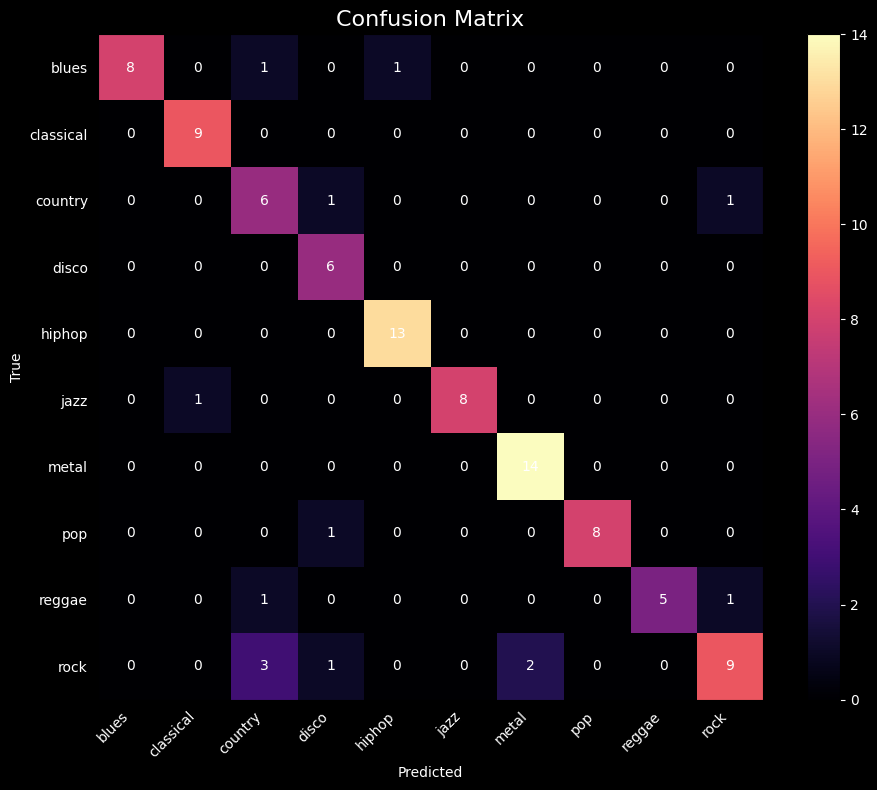

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

final_trainer = trainer_phase2

predictions = final_trainer.predict(gtzan["test"])
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

labels = [id2label[i] for i in range(num_labels)]
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8), facecolor="black")
ax.set_facecolor("black")

im = ax.imshow(cm, cmap="magma")

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", color="white")
ax.set_yticklabels(labels, color="white")

ax.set_xlabel("Predicted", color="white")
ax.set_ylabel("True", color="white")
ax.set_title("Confusion Matrix", color="white", fontsize=16)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="white")

cbar = plt.colorbar(im)
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.get_yticklabels(), color="white")

plt.tight_layout()
plt.show()

In order to see how we can improve our model, let's also display the training curves to see how it behave during training (by doing so, we can prevent overfitting for example)

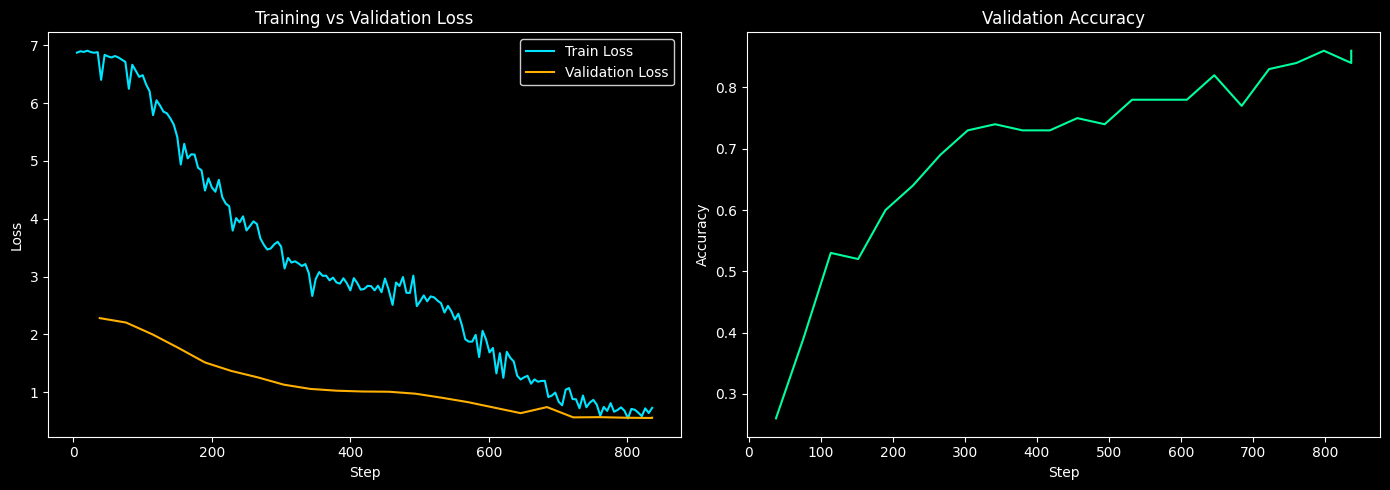

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

logs_phase1 = pd.DataFrame(trainer.state.log_history)
logs_phase2 = pd.DataFrame(trainer_phase2.state.log_history)

#oOffset phase 2 steps so curves follow each other
if "step" in logs_phase1.columns and "step" in logs_phase2.columns:
    offset = logs_phase1["step"].max()
    logs_phase2["step"] = logs_phase2["step"] + offset

logs = pd.concat([logs_phase1, logs_phase2], ignore_index=True)

train_loss = logs[logs["loss"].notnull()][["step", "loss"]]
eval_logs = logs[logs["eval_loss"].notnull()][["step", "eval_loss", "eval_accuracy"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="black")

for ax in axes:
    ax.set_facecolor("black")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for spine in ax.spines.values():
        spine.set_color("white")

axes[0].plot(train_loss["step"], train_loss["loss"], label="Train Loss", color="#00E5FF")
axes[0].plot(eval_logs["step"], eval_logs["eval_loss"], label="Validation Loss", color="#FFB000")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].legend(facecolor="black", edgecolor="white", labelcolor="white")

axes[1].plot(eval_logs["step"], eval_logs["eval_accuracy"], color="#00FF9C")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()